<a href="https://colab.research.google.com/github/sureshs59/sureshsunuguri/blob/main/SupervisedML_LinearReg.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Supervised Machine Learning: House Price Prediction with Linear Regression

### 1. What is Supervised Learning?

Supervised learning is a type of machine learning where an algorithm learns from a labeled dataset. A labeled dataset means that each training example comes with both input features (e.g., square footage of a house) and an output label (e.g., its price). The goal of the algorithm is to learn a mapping function from the input features to the output label so that it can accurately predict the labels for new, unseen data.

**Key Characteristics:**
*   **Labeled Data:** Requires data where the correct output is already known.
*   **Goal:** To predict an outcome or categorize data based on learned patterns.
*   **Common Tasks:** Regression (predicting a continuous value, like price) and Classification (predicting a discrete category, like spam/not-spam).

### 2. Problem: House Price Prediction

Imagine we want to predict the price of a house based on its size (square footage). This is a classic **regression** problem because we are trying to predict a continuous numerical value (price).

For simplicity, we'll generate a synthetic dataset where house prices are linearly related to their size, with some added random noise to make it more realistic.

First 5 rows of our synthetic dataset:


,SquareFootage,Price
0,1936.350297,101169.868268
1,3376.785766,153888.920778
2,2829.984855,146087.281553
3,2496.646210,25453.864795
4,1390.046601,58518.735663


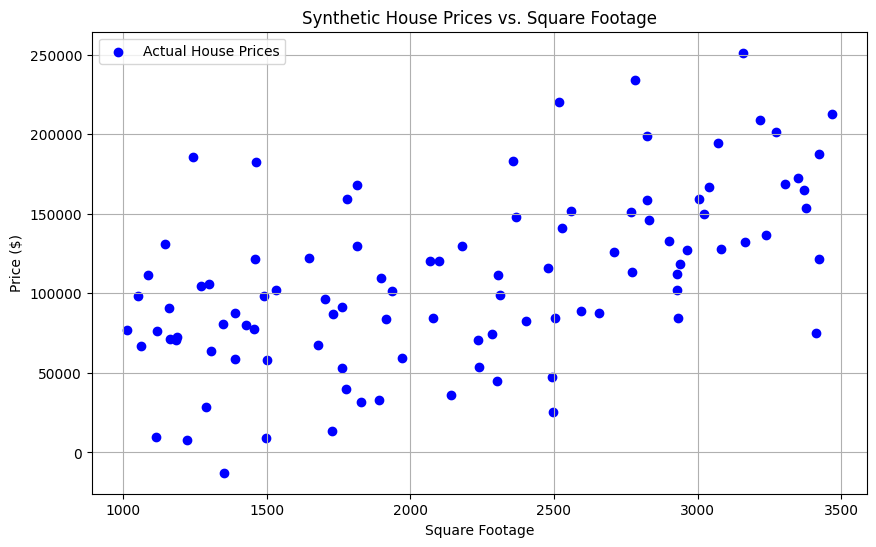

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# --- 3. Data Generation ---
np.random.seed(42)

# Generate synthetic data
num_houses = 100
sq_footage = np.random.uniform(1000, 3500, num_houses).reshape(-1, 1) # House sizes in sq ft
price = 50 * sq_footage + np.random.normal(0, 50000, num_houses).reshape(-1, 1) # Price in USD, with some noise

# Create a DataFrame for better organization
df = pd.DataFrame({'SquareFootage': sq_footage.flatten(), 'Price': price.flatten()})

print("First 5 rows of our synthetic dataset:")
display(df.head())

# Visualize the generated data
plt.figure(figsize=(10, 6))
plt.scatter(df['SquareFootage'], df['Price'], color='blue', label='Actual House Prices')
plt.title('Synthetic House Prices vs. Square Footage')
plt.xlabel('Square Footage')
plt.ylabel('Price ($)')
plt.grid(True)
plt.legend()
plt.show()

### 4. Model Selection: Linear Regression

**Linear Regression** is one of the simplest and most fundamental algorithms in machine learning. It assumes a linear relationship between the input features (independent variables, `X`) and the output variable (dependent variable, `y`).

The goal is to find the best-fitting straight line (or hyperplane in higher dimensions) that minimizes the sum of squared differences between the observed and predicted values.

Mathematically, for a single feature, it looks like:  `y = mx + b`
Where:
*   `y` is the predicted price
*   `x` is the square footage
*   `m` is the slope (how much price changes per unit of square footage)
*   `b` is the y-intercept (the predicted price when square footage is zero, though this might not be practically meaningful for real data).

### 5. Data Splitting: Training and Testing Sets

Before training, we split our data into two sets:
*   **Training Set:** Used to train the model (the model learns the patterns from this data).
*   **Test Set:** Used to evaluate the model's performance on unseen data. This is crucial to ensure the model generalizes well and doesn't just memorize the training data (overfitting).

In [10]:
# Define features (X) and target (y)
X = df[['SquareFootage']]
y = df['Price']

# Split data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set size: {len(X_train)} samples")
print(f"Test set size: {len(X_test)} samples")

Training set size: 80 samples
Test set size: 20 samples


### 6. Model Training

Now, we'll instantiate our `LinearRegression` model and train it using our training data. The `fit()` method is where the model learns the optimal `m` and `b` parameters.

Model trained successfully!
Learned coefficient (m): 41.97
Learned intercept (b): 15172.72


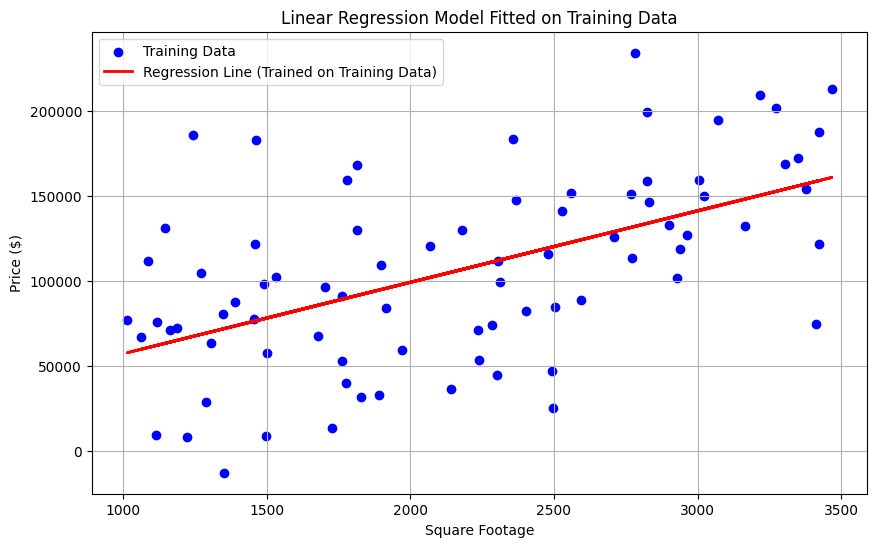

In [11]:
# Create a Linear Regression model instance
model = LinearRegression()

# Train the model using the training data
model.fit(X_train, y_train)

print(f"Model trained successfully!")
print(f"Learned coefficient (m): {model.coef_[0]:.2f}") # Slope
print(f"Learned intercept (b): {model.intercept_:.2f}") # Y-intercept

plt.figure(figsize=(10, 6))
plt.scatter(X_train, y_train, color='blue', label='Training Data')
plt.plot(X_train, model.predict(X_train), color='red', linewidth=2, label='Regression Line (Trained on Training Data)')
plt.title('Linear Regression Model Fitted on Training Data')
plt.xlabel('Square Footage')
plt.ylabel('Price ($)')
plt.grid(True)
plt.legend()
plt.show()

### 7. Prediction

Once the model is trained, we can use it to make predictions on new data, specifically our unseen test set.

First 5 actual vs. predicted prices on the test set:
Actual: $90,772.47, Predicted: $63,814.99
Actual: $136,679.64, Predicted: $151,042.02
Actual: $84,683.06, Predicted: $138,179.14
Actual: $87,345.91, Predicted: $126,665.70
Actual: $121,899.10, Predicted: $84,300.06


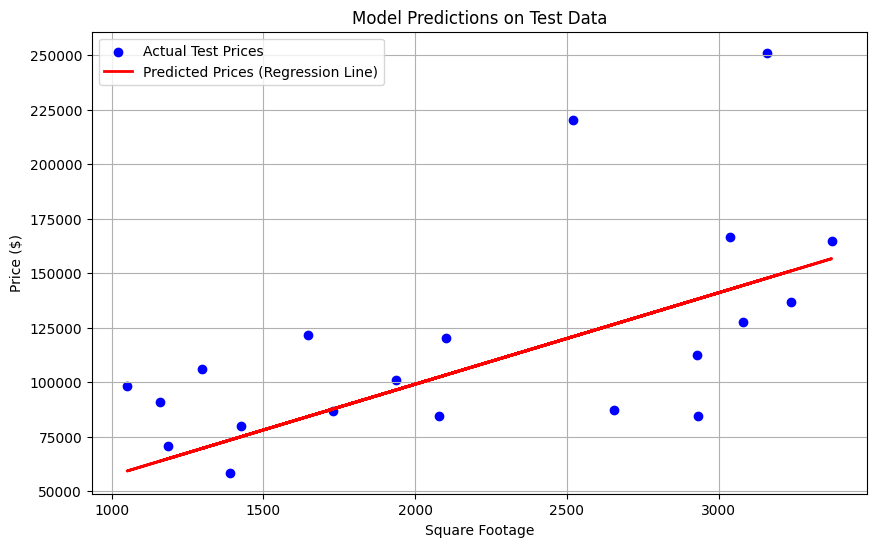

In [12]:
# Make predictions on the test set
y_pred = model.predict(X_test)

print("First 5 actual vs. predicted prices on the test set:")
for actual, predicted in zip(y_test.head(), y_pred[:5]):
    print(f"Actual: ${actual:,.2f}, Predicted: ${predicted:,.2f}")

# Visualize predictions on the test set
plt.figure(figsize=(10, 6))
plt.scatter(X_test, y_test, color='blue', label='Actual Test Prices')
plt.plot(X_test, y_pred, color='red', linewidth=2, label='Predicted Prices (Regression Line)')
plt.title('Model Predictions on Test Data')
plt.xlabel('Square Footage')
plt.ylabel('Price ($)')
plt.grid(True)
plt.legend()
plt.show()

### 8. Model Evaluation

To understand how well our model performs, we use evaluation metrics. For regression, common metrics include:

*   **Mean Squared Error (MSE):** The average of the squared differences between the actual and predicted values. Lower is better.
*   **R-squared (R²):** Represents the proportion of the variance in the dependent variable that is predictable from the independent variable(s). A value of 1 indicates a perfect fit, while 0 indicates the model explains none of the variance. Generally, higher is better.

In [9]:
# Evaluate the model's performance on the test set
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error (MSE) on Test Set: {mse:,.2f}")
print(f"R-squared (R²) on Test Set: {r2:.2f}")

# A perfect R2 (1.0) means the model explains all the variance.
# Our synthetic data is quite linear, so we expect a high R2.

Mean Squared Error (MSE) on Test Set: 1,634,248,784.29
R-squared (R²) on Test Set: 0.29


### 9. Beyond Basics: Expert Level Considerations

While linear regression is simple, real-world supervised learning involves much more:

*   **Feature Engineering:** Creating new features from existing ones (e.g., `price_per_sq_ft`, `age_of_house`). This is often the most impactful step.
*   **Multiple Features (Multivariate Regression):** Using more than one input variable (e.g., `SquareFootage`, `NumberBedrooms`, `Location`). The equation becomes `y = m1*x1 + m2*x2 + ... + mn*xn + b`.
*   **Non-linear Relationships:** For complex relationships, linear regression might not be sufficient. Consider polynomial regression (e.g., `y = ax^2 + bx + c`) or more advanced models like Decision Trees, Random Forests, Gradient Boosting Machines (XGBoost, LightGBM), or Neural Networks.
*   **Regularization (L1/L2):** Techniques like Ridge (L2) and Lasso (L1) regression prevent overfitting by adding penalties to the model's coefficients, making the model simpler.
*   **Cross-Validation:** A more robust way to evaluate model performance than a single train/test split. It involves splitting the data into multiple folds and training/testing the model multiple times.
*   **Hyperparameter Tuning:** Optimizing the model's settings (e.g., `max_depth` for a decision tree, `learning_rate` for boosting models) to achieve the best performance. Techniques include Grid Search and Random Search.
*   **Data Scaling/Normalization:** Essential for many algorithms (e.g., SVMs, Neural Networks, k-NN) to ensure features contribute equally to the model.
*   **Handling Categorical Features:** Converting non-numerical data (e.g., 'suburban', 'urban') into a numerical format (e.g., One-Hot Encoding).
*   **Model Interpretability:** Understanding *why* a model makes a certain prediction (e.g., using SHAP or LIME). This is crucial in high-stakes applications.
*   **Bias and Fairness:** Ensuring the model's predictions are fair across different demographic groups and do not perpetuate existing biases in the data.

This example provides a solid foundation for understanding supervised learning. As you progress, you'll delve into these more advanced techniques to build robust and accurate models for diverse real-world problems.